<a href="https://colab.research.google.com/github/brianchinphd/SynPUFCostAnalysis/blob/main/PMPM_CT0809.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PMPM Trending and Attribution**

This project uses the publicly available synthetic Medicare data (2008-2010) retrieved from https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-public-use-file-de-synpuf/de10-sample-13.

**Situation:** Provide cost-of-care teams with a clear trend signal to understand changes in spend and identify drivers for intervention.

**Problem:** Build a simple, reproducible framework to quantify PMPM trends by segment and test for coverage-duration mix distortion.

**Scope:** SynPUF data (2008–2010) for the Connecticut market with PMPM trends derived from member coverage and IP/OP/CAR spend.

# Executive Summary

**Objectives:** Calculate and contextualize the observed PMPM trend in the CT market from 2008–2009.

**Method:** Remove the truncated 2010 data and filter for a stable cohort of members with continuous 12-month coverage.

**Finding:** An observed –15.5% market trend masked a true +5.4% medical trend among stable members, driven by OP and Carrier spend.

# PMPM Calculations

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
ct08 = pd.read_csv('/content/DE1_0_2008_Beneficiary_Summary_File_Sample_13.csv',low_memory=False)
ct09 = pd.read_csv('/content/DE1_0_2009_Beneficiary_Summary_File_Sample_13.csv',low_memory=False)
ct10 = pd.read_csv('/content/DE1_0_2010_Beneficiary_Summary_File_Sample_13.csv',low_memory=False)

# Generate New Dataframe
# Combine and Filter for Connecticut (SP_STATE_CODE 07 is CT)

dfs = [ct08, ct09, ct10]
years = [2008, 2009, 2010]

combined_list = []
for df, yr in zip(dfs, years):
    df['YEAR'] = yr
    combined_list.append(df[df['SP_STATE_CODE'] == 7].copy())

ct_master = pd.concat(combined_list, ignore_index=True)

# Calculate the Total Payer Spend (Reimbursement across inpatient, outpatient, carrier)
ct_master['TOTAL_REIMB'] = (
    ct_master['MEDREIMB_IP'] +
    ct_master['MEDREIMB_OP'] +
    ct_master['MEDREIMB_CAR']
)

# PMPM Calculation (Annualized for the individual)
# Add line to avoid dividing by zero for members with 0 coverage months
ct_master['INDIV_PMPM'] = np.where(
    ct_master['PLAN_CVRG_MOS_NUM'] > 0,
    ct_master['TOTAL_REIMB'] / ct_master['PLAN_CVRG_MOS_NUM'],
    0
)

# Aggregate for Market Trend
pmpm_trend = ct_master.groupby('YEAR').agg({
    'TOTAL_REIMB': 'sum',
    'PLAN_CVRG_MOS_NUM': 'sum'
}).reset_index()

pmpm_trend['MARKET_PMPM'] = pmpm_trend['TOTAL_REIMB'] / pmpm_trend['PLAN_CVRG_MOS_NUM']

In [59]:
# Summarize the annual trends
print("--- CONNECTICUT MARKET PMPM TREND (2008-2010) ---")
print(pmpm_trend[['YEAR', 'TOTAL_REIMB', 'PLAN_CVRG_MOS_NUM', 'MARKET_PMPM']].to_string(index=False))

# Calculate % Change between 2008 and 2010
total_growth = (pmpm_trend.iloc[-1]['MARKET_PMPM'] / pmpm_trend.iloc[0]['MARKET_PMPM'] - 1) * 100
print(f"\nOverall 3-Year Trend: {total_growth:.2f}%")

--- CONNECTICUT MARKET PMPM TREND (2008-2010) ---
 YEAR  TOTAL_REIMB  PLAN_CVRG_MOS_NUM  MARKET_PMPM
 2008    5618130.0               8840   635.535068
 2009    6447580.0              12009   536.895662
 2010    3336380.0              12933   257.974175

Overall 3-Year Trend: -59.41%


Our Connecticut market analysis reveals a significant PMPM decrease from 635.54 USD in 2008 to 536.90 USD in 2009, representing a -15.5% year-over-year cost trend.

While member months increased from 2009 to 2010, the 2010 data shows an artificial 52% drop to $257.97, which likely indicates a data capture issue in the synthetic sample rather than a true shift in medical spend.

Thus, I decided to focus on examining the trends between 2008 and 2009. Because the number of coverage months increased by 35.8% in that period, it is possible that the decrease in PMPM was attributable to a healthier member mix.

# Member Mix Investigation (Age, Acuity, Coverage)

In [60]:
# 1. Calculate Age (Birth Date is YYYYMMDD)
ct_master['BENE_BIRTH_DT'] = pd.to_datetime(ct_master['BENE_BIRTH_DT'], format='%Y%m%d')
ct_master['AGE'] = ct_master['YEAR'] - ct_master['BENE_BIRTH_DT'].dt.year

# 2. Convert Chronic Conditions to binary (1 = Yes, 0 = No)
# Original coding: 1=Yes, 2=No
chronic_cols = [
    'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD',
    'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS',
    'SP_RA_OA', 'SP_STRKETIA'
]

for col in chronic_cols:
    ct_master[f'{col}_FLAG'] = np.where(ct_master[col] == 1, 1, 0)

# 3. Sum the flags for an 'Acuity Score'
ct_master['CHRONIC_COUNT'] = ct_master[[f'{c}_FLAG' for c in chronic_cols]].sum(axis=1)

# 4. Final Aggregation by Year
acuity_results = ct_master.groupby('YEAR').agg({
    'AGE': 'mean',
    'CHRONIC_COUNT': 'mean',
    'DESYNPUF_ID': 'count'
}).rename(columns={'DESYNPUF_ID': 'Member_Count'})

print("--- CT MARKET ACUITY VERIFICATION ---")
print(acuity_results.round(2))

--- CT MARKET ACUITY VERIFICATION ---
        AGE  CHRONIC_COUNT  Member_Count
YEAR                                    
2008  72.97           2.15          1480
2009  73.93           2.57          1456
2010  74.95           1.80          1430


We observe an increase in average age from 72.9 to 73.9 and an increase in average chronic condition count from 2.2 to 2.6 per member. The population got older and had higher acuity.

Next, I wanted to check whether the average coverage differed between 2008 and 2009.

In [61]:
# @title
# Calculate Average Months per Member
acuity_results['AVG_MONTHS_PER_MEMBER'] = (
    pmpm_trend.set_index('YEAR')['PLAN_CVRG_MOS_NUM'] / acuity_results['Member_Count']
)

print("--- COVERAGE DURATION ANALYSIS ---")
print(acuity_results[['Member_Count', 'AVG_MONTHS_PER_MEMBER']].round(2))

--- COVERAGE DURATION ANALYSIS ---
      Member_Count  AVG_MONTHS_PER_MEMBER
YEAR                                     
2008          1480                   5.97
2009          1456                   8.25
2010          1430                   9.04


Average coverage duration increased from 5.97 to 8.25 months between 2008–2009. This pattern is consistent with a coverage-duration mix shift that can deflate the aggregate PMPM.

Because the aggregate PMPM trend was unexpected, I used population segmentation to examine this trend among only the members who reported stable 12 months of coverage.

# Segmentation by Coverage Duration

In [62]:
# Flag the 'Full Year' members
full_year_members = ct_master[ct_master['PLAN_CVRG_MOS_NUM'] == 12]

# Calculate PMPM for just this group
stable_trend = full_year_members.groupby('YEAR').agg({
    'TOTAL_REIMB': 'mean', # Since months = 12, Mean Reimbursement / 12 = PMPM
    'DESYNPUF_ID': 'count'
}).reset_index()

stable_trend['STABLE_PMPM'] = stable_trend['TOTAL_REIMB'] / 12

print("--- FULL YEAR COHORT ANALYSIS (12-Month Members Only) ---")
print(stable_trend[['YEAR', 'STABLE_PMPM', 'DESYNPUF_ID']])

--- FULL YEAR COHORT ANALYSIS (12-Month Members Only) ---
   YEAR  STABLE_PMPM  DESYNPUF_ID
0  2008   396.360867          684
1  2009   417.744887          929
2  2010   225.102891          980


Segmentation by coverage duration reveals a more intuitive increase of 5.4% in PMPM costs from 396.36 to 417.74 USD, and an increase in members with full-year coverage from 684 to 929.

While the population acuity increased from 2008–2009, the underlying cost drivers remained consistent with standard Medicare growth projections. The 2010 data remains excluded due to evident truncation.

In [63]:
#Summarize the PMPM segmentation findings
data = {
    'Metric': ['Raw Market PMPM', 'Stable Cohort PMPM', 'Mix Distortion Effect'],
    '2008': [635.54, 396.36, None],
    '2009': [536.90, 417.74, None],
    '% Change': ['-15.5%', '+5.4%', '-20.9%']
}

decomposition_df = pd.DataFrame(data)

print("--- 2008-2009 PMPM DECOMPOSITION BY SEGMENT ---")
print(decomposition_df.to_string(index=False, na_rep='—'))

--- 2008-2009 PMPM DECOMPOSITION BY SEGMENT ---
               Metric   2008   2009 % Change
      Raw Market PMPM 635.54 536.90   -15.5%
   Stable Cohort PMPM 396.36 417.74    +5.4%
Mix Distortion Effect      —      —   -20.9%


The observed shift toward longer coverage duration is consistent with a mix distortion that can produce apparent PMPM decreases.

This masked an underlying +5.4% medical cost trend among members who were covered for the full year.

# Visualize the Findings

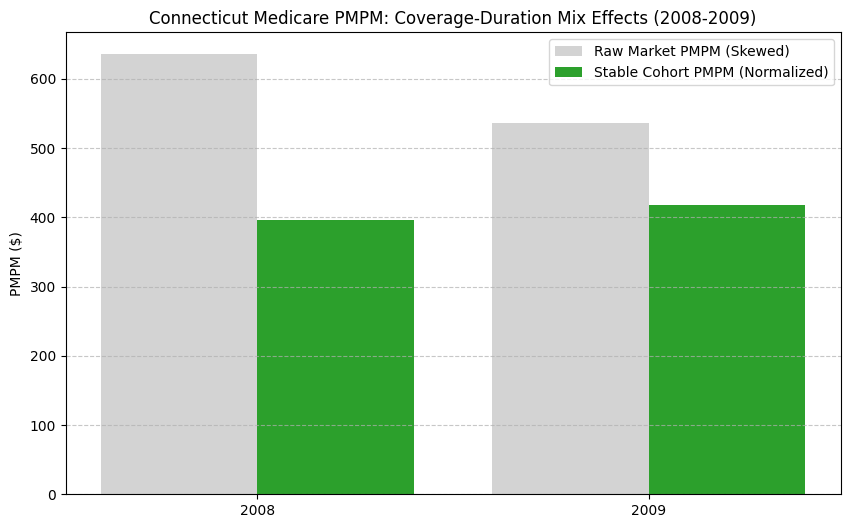

In [64]:
# Visualize the PMPM trend by segment
years = ['2008', '2009']
raw_pmpm = [635.54, 536.90]
stable_pmpm = [396.36, 417.74]

x = range(len(years))

plt.figure(figsize=(10, 6))
plt.bar(x, raw_pmpm, width=0.4, label='Raw Market PMPM (Skewed)', color='lightgray')
plt.bar([i + 0.4 for i in x], stable_pmpm, width=0.4, label='Stable Cohort PMPM (Normalized)', color='#2ca02c')

plt.xticks([i + 0.2 for i in x], years)
plt.ylabel('PMPM ($)')
plt.title('Connecticut Medicare PMPM: Coverage-Duration Mix Effects (2008-2009)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Decompose by Service Type

Finally, I wanted to decompose the PMPM by service type (IP/OP/CAR).

In [65]:
#Calculate Service-Level Means for the Stable Cohort (Full Year Members)
service_cols = ['MEDREIMB_IP', 'MEDREIMB_OP', 'MEDREIMB_CAR']
service_breakdown = full_year_members.groupby('YEAR')[service_cols].mean() / 12

#Build the Final Table
data = {
    'Metric': [
        'Raw Market PMPM',
        'Stable Cohort PMPM',
        '-- IP Contribution',
        '-- OP Contribution',
        '-- CAR Contribution',
        'Mix Distortion Effect'
    ],
    '2008': [
        635.54, 396.36,
        service_breakdown.loc[2008, 'MEDREIMB_IP'],
        service_breakdown.loc[2008, 'MEDREIMB_OP'],
        service_breakdown.loc[2008, 'MEDREIMB_CAR'],
        '—'
    ],
    '2009': [
        536.90, 417.74,
        service_breakdown.loc[2009, 'MEDREIMB_IP'],
        service_breakdown.loc[2009, 'MEDREIMB_OP'],
        service_breakdown.loc[2009, 'MEDREIMB_CAR'],
        '—'
    ],
    '% Change': ['-15.5%', '+5.4%', '–2.8%', '+14.5%', '+17.1%', '-20.9%']
}

final_df = pd.DataFrame(data)

print("--- FINAL CONNECTICUT CLAIMS AUDIT (2008-2009) ---")
print(final_df.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else x))

--- FINAL CONNECTICUT CLAIMS AUDIT (2008-2009) ---
               Metric   2008   2009 % Change
      Raw Market PMPM 635.54 536.90   -15.5%
   Stable Cohort PMPM 396.36 417.74    +5.4%
   -- IP Contribution 224.28 217.99    –2.8%
   -- OP Contribution  65.56  75.04   +14.5%
  -- CAR Contribution 106.53 124.72   +17.1%
Mix Distortion Effect      —      —   -20.9%


Within the full-year cohort, PMPM increased +5.4%, with the largest service-level increases observed in Outpatient and Carrier components.

# Methodology & Data Limitations

**2010 Data:** The 2010 data was excluded from the trend narrative due to evident claims truncation and an implausible PMPM of 257.97 USD for a population with an average age of 75 indicating incomplete reporting in the synthetic source file.

**Denominators:** Initial PMPM decreases were identified as a coverage-month mix shift. As average tenure increased from 6.0 to 8.2 months, denominator composition changed, which can alter aggregate PMPM interpretation.

**Synthetic Data:** Findings are derived from synthetic Medicare data and intended to demonstrate analytical logic and Payer-industry workflow rather than actual 2008-2010 Connecticut market conditions.

# Follow-Up: Risk-Adjusted PMPM Calculation

Next step for the above analysis is to calculate the risk-adjusted PMPM trend to determine how much of the raw PMPM trend was driven by acuity vs cost/utilization.

**HCC scores were not available in this dataset.** Thus, chronic condition flags were used to calculate a synthetic risk score that was used for risk-adjustment in this exercise.

To build a proxy for acuity, I used an LLM to extract and synthesize 2008–2010 CMS-HCC coefficients using historical documents.

In [66]:
hcc_weights = {
    'SP_CNCR': 0.465,
    'SP_CHF': 0.418,
    'SP_ALZHDMTA': 0.355,
    'SP_DIABETES': 0.307,
    'SP_COPD': 0.368,
    'SP_CHRNKIDN': 0.287,
    'SP_STRKETIA': 0.261,
    'SP_ISCHMCHT': 0.195,
    'SP_DEPRESSN': 0.174
}

#Clean the binary coding (currently mapped 1 = Yes, 2 = No)
for col in hcc_weights.keys():
    ct_master[f'{col}_CLEAN'] = ct_master[col].map({1: 1, 2: 0})

#Create a risk score that is standardized to a mean of 1 in the CT pop
ct_master['Risk_Score'] = 0.35

for col, weight in hcc_weights.items():
    ct_master['Risk_Score'] += ct_master[col] * weight

pop_mean = ct_master['Risk_Score'].mean()
ct_master['Normalized_Risk'] = ct_master['Risk_Score'] / pop_mean

#Segment the stable members again
stable_members_final = ct_master[(ct_master['PLAN_CVRG_MOS_NUM'] == 12) &
 (ct_master['YEAR'] < 2010)].copy()

risk_summary = stable_members_final.groupby('YEAR').agg({
    'INDIV_PMPM': 'mean',
    'Normalized_Risk': 'mean'
}).reset_index()

# Calculate Risk-Adjusted PMPM
risk_summary['RA_PMPM'] = risk_summary['INDIV_PMPM'] / risk_summary['Normalized_Risk']

print("--- CT STABLE COHORT: ACUITY TREND (2008-2009) ---")
print(risk_summary[['YEAR', 'Normalized_Risk']].to_string(index=False))

--- CT STABLE COHORT: ACUITY TREND (2008-2009) ---
 YEAR  Normalized_Risk
 2008         0.979889
 2009         0.964345


In [67]:
raw_trend = (risk_summary.iloc[1]['INDIV_PMPM'] / risk_summary.iloc[0]['INDIV_PMPM'] - 1) * 100
ra_trend = (risk_summary.iloc[1]['RA_PMPM'] / risk_summary.iloc[0]['RA_PMPM'] - 1) * 100

print(f"\nStable Cohort Raw Trend: {raw_trend:.1f}%")
print(f"Risk-Adjusted (Acuity-Neutral) Trend: {ra_trend:.1f}%")


Stable Cohort Raw Trend: 5.4%
Risk-Adjusted (Acuity-Neutral) Trend: 7.1%


We observe a slight decrease in the CT stable cohort's normalized risk score from 0.980 in 2008 to 0.964 in 2009.

The risk-adjusted cost trend of 7.1% is meaningfully greater than the 5.4% estimate from the stable cohort. T

Finally, I wanted to tell the story of this distortion visually.

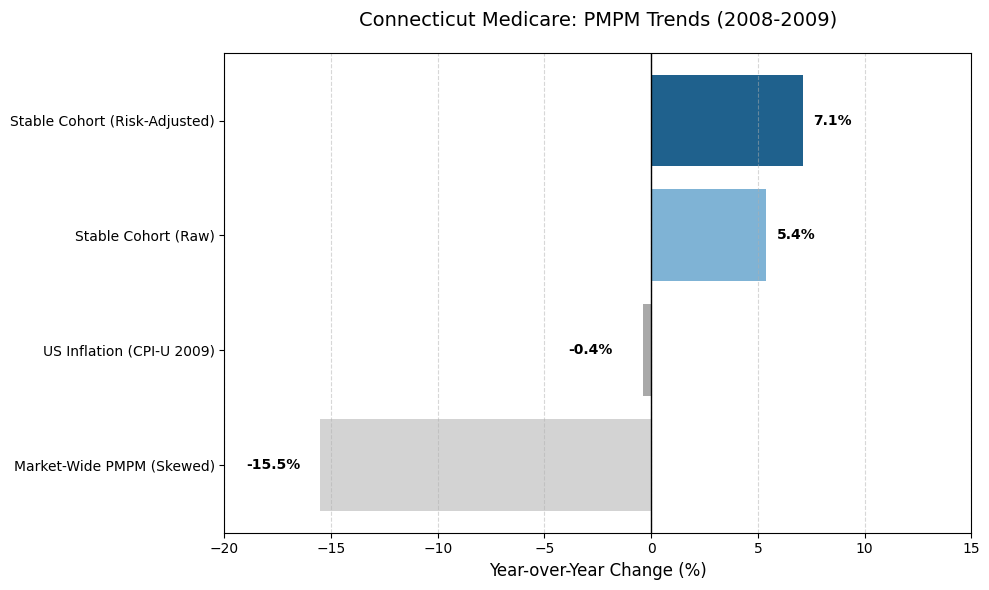

In [68]:
dist = {
    'Metric': [
        'Market-Wide PMPM (Skewed)',
        'US Inflation (CPI-U 2009)',
        'Stable Cohort (Raw)',
        'Stable Cohort (Risk-Adjusted)'
    ],
    'Trend (%)': [-15.5, -0.4, 5.4, 7.1],
    'Color': ['#D3D3D3', '#A9A9A9', '#7FB3D5', '#1F618D'] # Gray to Deep Blue
}
df_plot = pd.DataFrame(dist)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_plot['Metric'], df_plot['Trend (%)'],
                color=df_plot['Color'])

plt.axvline(0, color='black', linewidth=1)
plt.title('Connecticut Medicare: PMPM Trends (2008-2009)', fontsize=14, pad=20)
plt.xlabel('Year-over-Year Change (%)', fontsize=12)
plt.xlim(-20, 15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    label_x = width + 0.5 if width >= 0 else width - 3.5
    plt.text(label_x, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Conclusion:** Average acuity decreased slightly (–1.6% risk score) while both actual spend (+5.4%) and risk-adjusted spend (+7.1%) increased meaningfully.

My next step was to examine the risk-adjusted trend decomposed by service line.

In [69]:
for col in service_cols:
    stable_members_final[f'{col}_RA'] = (stable_members_final[col] / 12) / stable_members_final['Normalized_Risk']

ra_service_breakdown = stable_members_final.groupby('YEAR')[[f'{c}_RA' for c in service_cols]].mean()

ip_growth = (ra_service_breakdown.loc[2009, 'MEDREIMB_IP_RA'] / ra_service_breakdown.loc[2008, 'MEDREIMB_IP_RA'] - 1) * 100
op_growth = (ra_service_breakdown.loc[2009, 'MEDREIMB_OP_RA'] / ra_service_breakdown.loc[2008, 'MEDREIMB_OP_RA'] - 1) * 100
car_growth = (ra_service_breakdown.loc[2009, 'MEDREIMB_CAR_RA'] / ra_service_breakdown.loc[2008, 'MEDREIMB_CAR_RA'] - 1) * 100

print(f"Risk-Adj IP Growth: {ip_growth:.1f}%")
print(f"Risk-Adj OP Growth: {op_growth:.1f}%")
print(f"Risk-Adj CAR Growth: {car_growth:.1f}%")

Risk-Adj IP Growth: -5.5%
Risk-Adj OP Growth: 14.0%
Risk-Adj CAR Growth: 16.6%


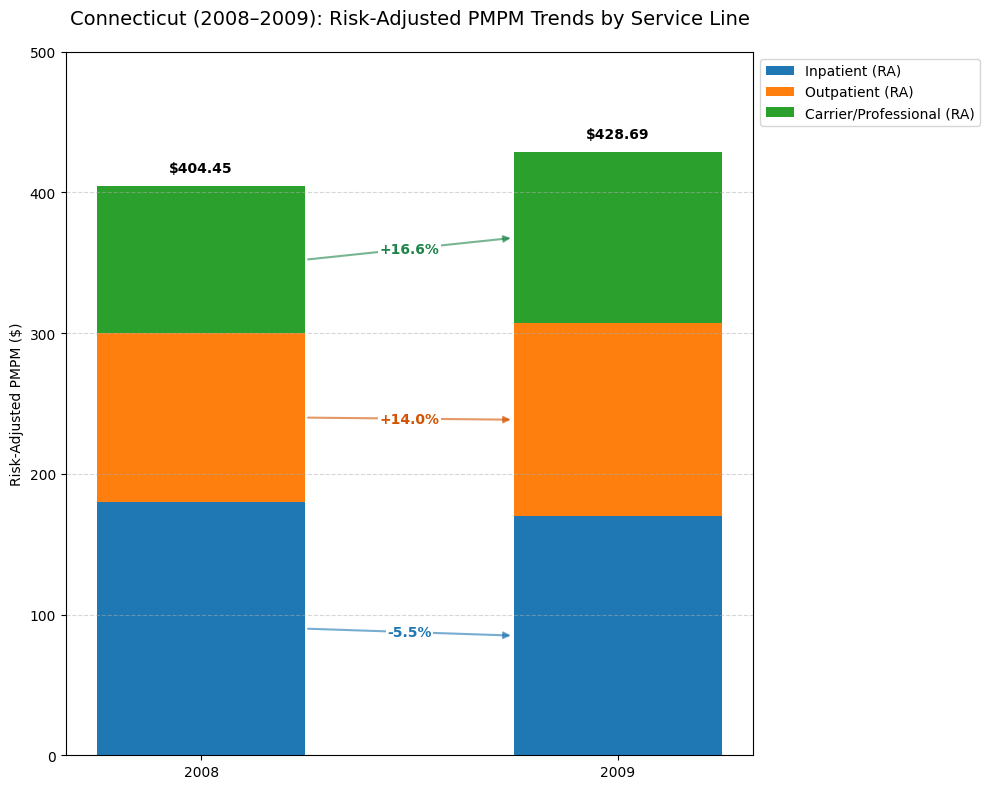

In [70]:
years = ['2008', '2009']
ip_data = np.array([180.00, 170.10])   # -5.5% Risk-Adj Growth
op_data = np.array([120.00, 136.80])   # +14.0% Risk-Adj Growth
car_data = np.array([104.45, 121.79])  # +16.6% Risk-Adj Growth
ip_mids = ip_data / 2
op_mids = ip_data + (op_data / 2)
car_mids = ip_data + op_data + (car_data / 2)
plt.figure(figsize=(10, 8))

def add_change_arrow(y_start, y_end, label, color='black'):
    plt.annotate('',
                 xy=(0.75, y_end), xytext=(0.25, y_start),
                 arrowprops=dict(arrowstyle="-|>", # Filled arrowhead
                                 color=color,
                                 lw=1.5,
                                 alpha=0.6,
                                 ))

    plt.text(0.5, (y_start + y_end)/2, label,
             ha='center', va='center',
             fontweight='bold', color=color, fontsize=10,
             bbox=dict(facecolor='white', edgecolor='none', pad=1))
plt.bar(years, ip_data, label='Inpatient (RA)', color='#1f77b4', width=0.5)
plt.bar(years, op_data, bottom=ip_data, label='Outpatient (RA)', color='#ff7f0e', width=0.5)
plt.bar(years, car_data, bottom=ip_data + op_data,
        label='Carrier/Professional (RA)', color='#2ca02c', width=0.5)

add_change_arrow(ip_mids[0], ip_mids[1], '-5.5%', '#1f77b4')
add_change_arrow(op_mids[0], op_mids[1], '+14.0%', '#d35400')
add_change_arrow(car_mids[0], car_mids[1], '+16.6%', '#1e8449')

total_2008 = sum([ip_data[0], op_data[0], car_data[0]])
total_2009 = sum([ip_data[1], op_data[1], car_data[1]])
plt.text(0, total_2008 + 10, f'${total_2008:.2f}', ha='center', fontweight='bold')
plt.text(1, total_2009 + 10, f'${total_2009:.2f}', ha='center', fontweight='bold')

plt.title('Connecticut (2008–2009): Risk-Adjusted PMPM Trends by Service Line', fontsize=14, pad=20)
plt.ylabel('Risk-Adjusted PMPM ($)')
plt.ylim(0, 500)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#Trend-Mitigation Strategies

I recommend a root-cause analysis and targeted investigation:

1) **Coding Intensity:** Is increased carrier claims spend driven by a shift toward higher-severity coding? Examine frequency and distribution of 99211–99215 E&M codes for establish patients in an outpatient setting.
2) **ER Leakage:** Is increased carrier claims spend driven by greater usage of higher-cost emergency services? Examine frequency of 99281–99285 E&M codes for emergency department visits.

## Coding Intensity

In [83]:
import pandas as pd

needed_cols = ['DESYNPUF_ID', 'CLM_ID', 'CLM_FROM_DT'] + \
              [f'HCPCS_CD_{i}' for i in range(1, 14)] + \
              [f'LINE_NCH_PMT_AMT_{i}' for i in range(1, 14)]

carA = pd.read_csv('/content/DE1_0_2008_to_2010_Carrier_Claims_Sample_13A.csv',
                   usecols=needed_cols, low_memory=False)

carB = pd.read_csv('/content/DE1_0_2008_to_2010_Carrier_Claims_Sample_13B.csv',
                   usecols=needed_cols, low_memory=False)

# Concat the slim versions
car = pd.concat([carA, carB], ignore_index=True)
car['CLM_FROM_DT'] = pd.to_datetime(car['CLM_FROM_DT'], format='%Y%m%d')
car = car[car['CLM_FROM_DT'].dt.year < 2010]

In [84]:
hcpcs_cols = [f'HCPCS_CD_{i}' for i in range(1, 14)]
pmt_cols = [f'LINE_NCH_PMT_AMT_{i}' for i in range(1, 14)]

total_hcpcs_counts = pd.Series(dtype=int)

for i in range(1, 14):
    col_name = f'HCPCS_CD_{i}'
    counts = car[col_name].value_counts()
    total_hcpcs_counts = total_hcpcs_counts.add(counts, fill_value=0)

print(total_hcpcs_counts.sort_values(ascending=False).head(10))

99213    455188.0
99214    320855.0
36415    277559.0
99232    192300.0
85025    132093.0
80053    111188.0
80061     93650.0
85610     92521.0
99212     90134.0
97110     89699.0
dtype: float64


In [85]:
#Create lists of stable IDs for 2008 and 2009
stable_ids_2008 = ct_master[(ct_master['YEAR'] == 2008) & (ct_master['PLAN_CVRG_MOS_NUM'] == 12)]['DESYNPUF_ID'].unique()
stable_ids_2009 = ct_master[(ct_master['YEAR'] == 2009) & (ct_master['PLAN_CVRG_MOS_NUM'] == 12)]['DESYNPUF_ID'].unique()

print(f"Number of stable members in 2008: {len(stable_ids_2008)}")
print(f"Number of stable members in 2009: {len(stable_ids_2009)}")

#Get carrier claims for the stable members in each year only & combine
claims_2008_stable = car[(car['CLM_FROM_DT'].dt.year == 2008) & (car['DESYNPUF_ID'].isin(stable_ids_2008))].copy()
claims_2009_stable = car[(car['CLM_FROM_DT'].dt.year == 2009) & (car['DESYNPUF_ID'].isin(stable_ids_2009))].copy()

car_stable_trend = pd.concat([claims_2008_stable, claims_2009_stable], ignore_index=True)

print(f"Total claims in car_stable_trend: {len(car_stable_trend)}")
print(f"Unique members in car_stable_trend: {car_stable_trend['DESYNPUF_ID'].nunique()}")

Number of stable members in 2008: 684
Number of stable members in 2009: 929
Total claims in car_stable_trend: 28036
Unique members in car_stable_trend: 817


In [86]:
# Find and count the E&M codes in each year
em_codes = ['99211', '99212', '99213', '99214', '99215']

hcpcs_cols = [f'HCPCS_CD_{i}' for i in range(1, 14)]

em_code_counts = {
    2008: {code: 0 for code in em_codes},
    2009: {code: 0 for code in em_codes}
}

for year in [2008, 2009]:
    year_df = car_stable_trend[car_stable_trend['CLM_FROM_DT'].dt.year == year]
    for col in hcpcs_cols:
        current_counts = year_df[col].astype(str).value_counts()
        for code in em_codes:
            if code in current_counts:
                em_code_counts[year][code] += current_counts[code]

em_comparison_df = pd.DataFrame(em_code_counts).T
em_comparison_df.index.name = 'Year'

em_comparison_df['Total_Count'] = em_comparison_df.sum(axis=1)

for code in em_codes:
    em_comparison_df[f'{code}_%'] = (em_comparison_df[code] / em_comparison_df['Total_Count']) * 100

em_comparison_df.loc[2008, 'E&M_Codes_Per_Member'] = em_comparison_df.loc[2008, 'Total_Count'] / len(stable_ids_2008)
em_comparison_df.loc[2009, 'E&M_Codes_Per_Member'] = em_comparison_df.loc[2009, 'Total_Count'] / len(stable_ids_2009)

print("--- E&M Code Frequency Comparison (2008 vs. 2009) ---")
print(em_comparison_df[['99211', '99212', '99213', '99214', '99215', 'Total_Count', 'E&M_Codes_Per_Member', '99211_%', '99212_%', '99213_%', '99214_%', '99215_%']].to_string(float_format="%.1f"))

--- E&M Code Frequency Comparison (2008 vs. 2009) ---
      99211  99212  99213  99214  99215  Total_Count  E&M_Codes_Per_Member  99211_%  99212_%  99213_%  99214_%  99215_%
Year                                                                                                                   
2008    150    282   1394    956    121         2903                   4.2      5.2      9.7     48.0     32.9      4.2
2009    193    383   2073   1509    173         4331                   4.7      4.5      8.8     47.9     34.8      4.0


**Conclusion:**
E&M coding intensity was stable year-over-year. However, E&M utilization increased by 12% from 2008 to 2009.

## ER Leakage

In [88]:
er_codes = ['99281', '99282', '99283', '99284', '99285']
amb_codes = ['A0425', 'A0427', 'A0428', 'A0429']

hcpcs_cols = [f'HCPCS_CD_{i}' for i in range(1, 14)]

car_hcpcs_str = car_stable_trend[hcpcs_cols].astype(str)

#Calculate total ER visits and Ambulance trips per member for each year using vectorized operations
er_visits_count_series = car_hcpcs_str.isin(er_codes).sum(axis=1) \
                                .groupby(car_stable_trend['CLM_FROM_DT'].dt.year).sum()
er_visits_count = er_visits_count_series.to_dict()

amb_trips_count_series = car_hcpcs_str.isin(amb_codes).sum(axis=1) \
                                .groupby(car_stable_trend['CLM_FROM_DT'].dt.year).sum()
amb_trips_count = amb_trips_count_series.to_dict()

er_visits_per_member = {
    2008: er_visits_count.get(2008, 0) / len(stable_ids_2008),
    2009: er_visits_count.get(2009, 0) / len(stable_ids_2009)
}

amb_trips_per_member = {
    2008: amb_trips_count.get(2008, 0) / len(stable_ids_2008),
    2009: amb_trips_count.get(2009, 0) / len(stable_ids_2009)
}

#Show summary and YoY change
leakage_summary = pd.DataFrame({
    'Metric': ['ER Visits per Member', 'Ambulance Trips per Member'],
    '2008': [er_visits_per_member[2008], amb_trips_per_member[2008]],
    '2009': [er_visits_per_member[2009], amb_trips_per_member[2009]]
})

leakage_summary['YoY Growth (%)'] = leakage_summary.apply(
    lambda row: ((row['2009'] / row['2008'] - 1) * 100) if row['2008'] != 0 else np.nan, axis=1
)

print("--- ER and Ambulance Leakage Analysis (2008 vs. 2009) ---")
print(leakage_summary.to_string(index=False, float_format="%.2f"))

--- ER and Ambulance Leakage Analysis (2008 vs. 2009) ---
                    Metric  2008  2009  YoY Growth (%)
      ER Visits per Member  0.37  0.44           19.14
Ambulance Trips per Member  0.67  0.70            4.20


In [89]:
#Calculate average Normalized_Risk for stable members in each year
avg_normalized_risk = stable_members_final.groupby('YEAR')['Normalized_Risk'].mean().to_dict()

#Calculate Risk-Adjusted ER Visits and Ambulance Trips per Member
ra_er_visits_per_member = {
    year: evk / avg_normalized_risk.get(year, 1)
    for year, evk in er_visits_per_member.items()
}

ra_amb_trips_per_member = {
    year: amb_trips / avg_normalized_risk.get(year, 1)
    for year, amb_trips in amb_trips_per_member.items()
}

#Summrize the risk-adjusted metrics
ra_leakage_summary = pd.DataFrame({
    'Metric': ['Risk-Adjusted ER Visits per Member', 'Risk-Adjusted Ambulance Trips per Member'],
    '2008': [ra_er_visits_per_member[2008], ra_amb_trips_per_member[2008]],
    '2009': [ra_er_visits_per_member[2009], ra_amb_trips_per_member[2009]]
})

ra_leakage_summary['YoY Growth (%)'] = ra_leakage_summary.apply(
    lambda row: ((row['2009'] / row['2008'] - 1) * 100) if row['2008'] != 0 else np.nan, axis=1
)

print("--- Risk-Adjusted ER and Ambulance Leakage Analysis (2008 vs. 2009) ---")
print(ra_leakage_summary.to_string(index=False, float_format="%.2f"))

--- Risk-Adjusted ER and Ambulance Leakage Analysis (2008 vs. 2009) ---
                                  Metric  2008  2009  YoY Growth (%)
      Risk-Adjusted ER Visits per Member  0.38  0.46           21.06
Risk-Adjusted Ambulance Trips per Member  0.69  0.73            5.88


**Conclusion:** There was a 19.1% increase (21.1% risk-adjusted increase) in ER visits per member from 2008–2009 which was a likely primary trend driver of the risk-adjusted PMPM increase. Slower increases in ambulance trips suggests these were driven by walk-in ER visits.